## HW04: Data Modeling

---

Student Name: Lý Liên Hoa

Student ID: 22127117

---

## Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

---

## Data collecting

The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine. For more details, consult: http://www.vinhoverde.pt/en/ or the reference [Cortez et al., 2009].  Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.). You can download these data from this [link](https://archive.ics.uci.edu/dataset/186/wine+quality).

These datasets can be viewed as classification or regression tasks.  The classes are ordered and not balanced (e.g. there are many more normal wines than excellent or poor ones). Outlier detection algorithms could be used to detect the few excellent or poor wines. Also, we are not sure if all input variables are relevant. So it could be interesting to test feature selection methods.

---

## Exploring your data

### Read raw data from file

In [2]:
raw_white = pd.read_csv('./data/winequality-white.csv', sep = ';')
raw_red = pd.read_csv('./data/winequality-red.csv', sep = ';')

In [3]:
raw_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
raw_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Combine the two dataframes and add a `colors` column to distinguish between red and white wines. Named the dataframe as `raw_df`.

In [5]:
raw_white["colors"] = "white"
raw_red["colors"] = "red"
raw_df = pd.concat([raw_white, raw_red], ignore_index=True)

### How many rows and how many columns does the raw data have? (0.25 points)

In [6]:
shape_white = raw_white.shape
shape_red = raw_red.shape
shape = raw_df.shape

### What does each line mean? Does it matter if the lines have different meanings?

- Each line relates to a specific wine sample with attibutes, such as acidity, sugar level, chloride level, pH, quality rating.

- It matters when the lines have different meanings because it will cause inconsistency across lines which can lead to errors in analysis and wrong results.

### Does the raw data have duplicate rows? (0.25 points)

In [7]:
# YOUR CODE HERE
white_num_duplicated_rows = raw_white.duplicated().sum()
red_num_duplicated_rows = raw_red.duplicated().sum()

### What does each column mean? (0.25đ)

YOUR ANSWER HERE

| Attibutes           | Type        |
| :------------------ | ----------- |
| fixed acidity       | Continous   |
| volatile acidity    | Continous   |
| citrics acid        | Continous   |
| residual sugar      | Continous   |
| chlorides           | Continous   |
| free sulfur dioxide | Continous   |
| total sulfur dioxide| Continous   |
| density             | Continous   |
| pH                  | Continous   |
| sulphates           | Continous   |
| alcohol             | Continous   |
| quality             | Numerical   |
| color               | Categorical |

### What data type does each column currently have? Are there any columns whose data types are not suitable for further processing? (0.25 points)

In [8]:
white_dtypes = raw_white.dtypes
red_dtypes = raw_red.dtypes

In [9]:
white_dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
colors                   object
dtype: object

In [10]:
red_dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
colors                   object
dtype: object

### For each column with numeric data type, how are the values distributed? (1đ)

For columns with numeric data types, calculate:
- Percentage (from 0 to 100) of missing values
- The min
- The lower quartile (phân vị 25)
- The median (phân vị 50)
- The upper quartile (phân vị 75)
- The max

In [11]:
# YOUR CODE HERE
def missing_ratio(series):
    return series.isnull().sum() / len(series) * 100

def lower_quartile(series):
    return series.quantile(0.25)

def median(series):
    return series.median()

def upper_quartile(series):
    return series.quantile(0.75)

numeric_col_red = raw_red.select_dtypes(include=['number'])
num_col_info_red = numeric_col_red 

numeric_col_white = raw_white.select_dtypes(include=['number'])
num_col_info_white = numeric_col_white 

In [12]:
num_col_info_red = num_col_info_red.agg([missing_ratio, "min", lower_quartile, median, upper_quartile, "max"])
num_col_info_white = num_col_info_white.agg([missing_ratio, "min", lower_quartile, median, upper_quartile, "max"])

In [13]:
num_col_info_red

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
missing_ratio,0.0,0.00,0.00,0.0,0.000,0.0,0.0,0.000000,0.00,0.00,0.0,0.0
min,4.6,0.12,0.00,0.9,0.012,1.0,6.0,0.990070,2.74,0.33,8.4,3.0
lower_quartile,7.1,0.39,0.09,1.9,0.070,7.0,22.0,0.995600,3.21,0.55,9.5,5.0
median,7.9,0.52,0.26,2.2,0.079,14.0,38.0,0.996750,3.31,0.62,10.2,6.0
upper_quartile,9.2,0.64,0.42,2.6,0.090,21.0,62.0,0.997835,3.40,0.73,11.1,6.0
max,15.9,1.58,1.00,15.5,0.611,72.0,289.0,1.003690,4.01,2.00,14.9,8.0


### For each column with a non-numeric data type, how are the values distributed?(1đ)

For columns with non-numeric data types, calculate:
- Percentage (from 0 to 100) of missing values
- Number of values (the values here are different values and we do not consider missing values): with columns whose type is categorical, it is a set with a finite number of categories. Directly counting the number of values in these columns doesn't make much sense, so it's better to count the number of elements of all types.
- The percentage (from 0 to 100) of each value is sorted by decreasing percentage (we do not consider missing values, the ratio is the ratio compared to the number of non-missing values): you use a dictionary to store , key is the value, value is the percentage; With the column corresponding to each type, the method is similar to above.

In [14]:
# YOUR CODE HERE
def missing_ratio(column):
    return column.isnull().sum() / len(column) * 100

def num_values(column):
    return column.nunique()

def value_ratios(column):
    value_counts = column.value_counts(normalize=True) * 100
    ratio = value_counts.sort_values(ascending=False).round(1).to_dict()
    return ratio

cat_col_info_df = raw_df.select_dtypes(exclude=['number'])

In [15]:
# TEST
cat_col_info_df = cat_col_info_df.agg([missing_ratio, num_values, value_ratios])
cat_col_info_df

,colors
missing_ratio,0.0
num_values,2
value_ratios,"{'white': 75.4, 'red': 24.6}"


## Exploring your data (Cont)

### Wine quality via histogram.

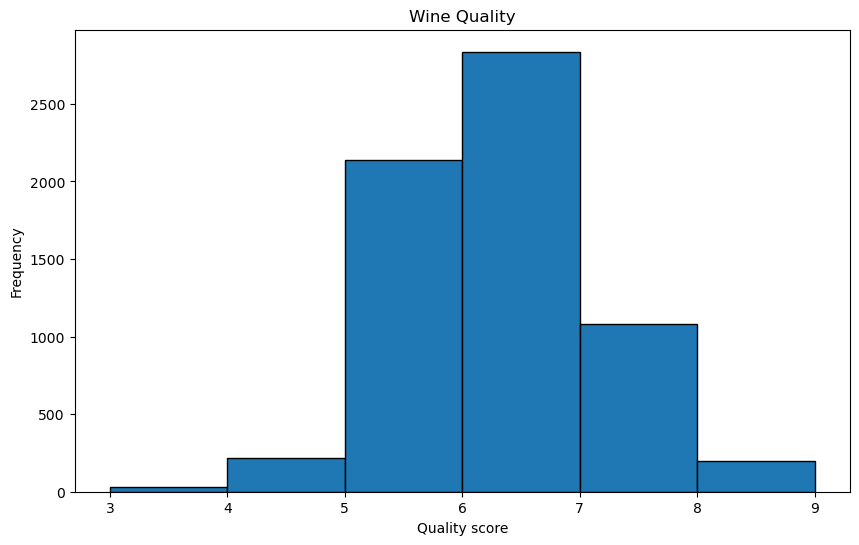

In [16]:
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
plt.hist(raw_df['quality'], bins=range(3, 10), label='Wine', edgecolor='black')

plt.title('Wine Quality')
plt.xlabel('Quality score')
plt.ylabel('Frequency')

plt.xticks(range(3, 10))

plt.show()

### Correlation matrix

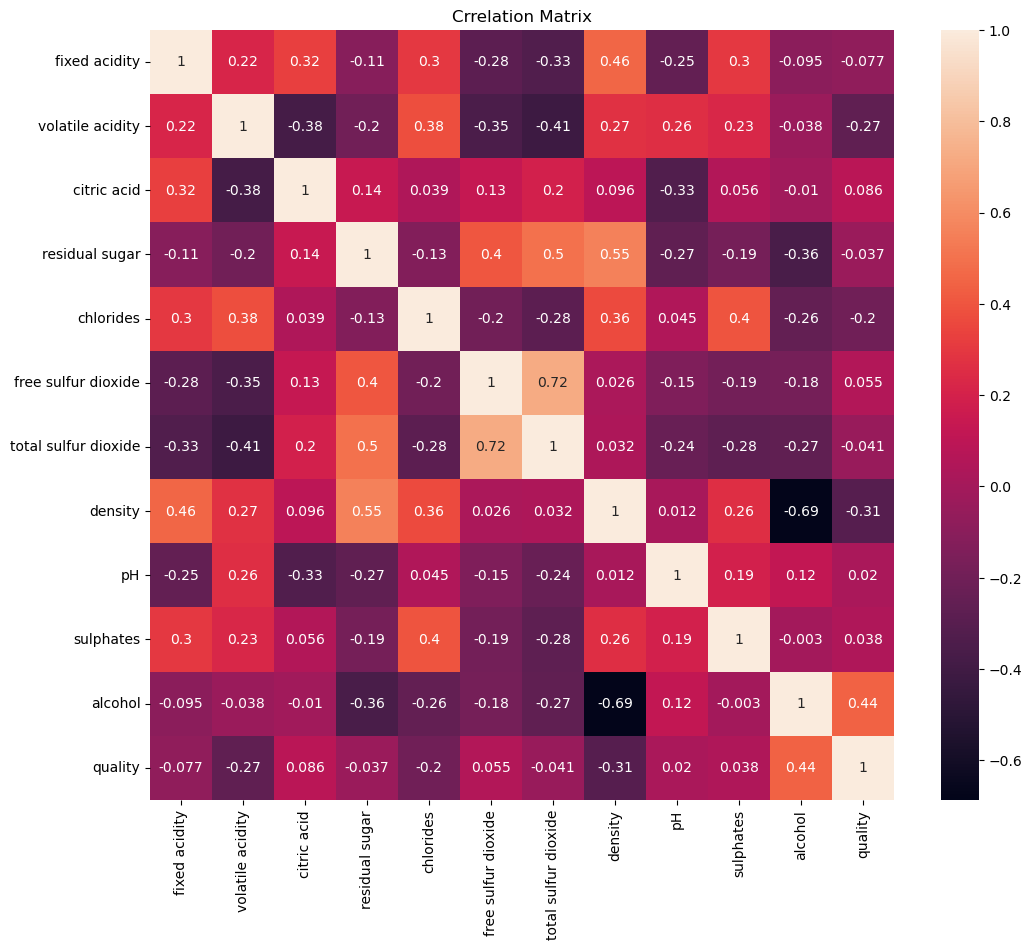

In [17]:
# YOUR CODE HERE
correlation_matrix = raw_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True)
plt.title("Crrelation Matrix")

plt.show()

## Data Modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import classification_report

### Splitting dataset

In [19]:
# Splitting dataset
X = raw_df.drop(columns=['quality', 'colors'])
y = raw_df['quality']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

### Normalization

In [20]:
# Normalization
norm = MinMaxScaler()

# Fit data
norm_fit = norm.fit(X_train)

new_X_train = norm_fit.transform(X_train)
new_X_valid = norm_fit.transform(X_valid)
new_X_test = norm_fit.transform(X_test)

print(new_X_train[:5])

[[0.19008264 0.06       0.1686747  0.06129032 0.02671119 0.1443299
  0.25520111 0.15494174 0.37288136 0.08       0.44927536]
 [0.26446281 0.04666667 0.1686747  0.45483871 0.06510851 0.19243986
  0.39667129 0.46568839 0.20338983 0.09142857 0.14492754]
 [0.2231405  0.07333333 0.19277108 0.02580645 0.04674457 0.20618557
  0.34951456 0.21881744 0.54237288 0.17714286 0.4057971 ]
 [0.2892562  0.14       0.18072289 0.4        0.05175292 0.30927835
  0.64355062 0.49503669 0.28813559 0.10285714 0.10144928]
 [0.2892562  0.18666667 0.37349398 0.20967742 0.03505843 0.32302405
  0.49653259 0.32757877 0.3559322  0.22285714 0.37681159]]


### Applying model

#### Random Forest Classifier

In [21]:
# Creating RandomForestClassifier constructor
rnd_model = RandomForestClassifier(random_state=42)

# Train model
rnd_model.fit(new_X_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
# Prediction on validation set
y_valid_pred_c = rnd_model.predict(new_X_valid)

# Evaluate model on validation set
valid_accuracy_c = accuracy_score(y_valid, y_valid_pred_c)
print(f"Accuracy on validation set: {valid_accuracy_c}")

Accuracy on validation set: 0.6851282051282052


In [23]:
# Validation set
# Calculating MSE (Mean Square Error)
rnd_valid_MSE = mean_squared_error(y_valid, y_valid_pred_c)

# Calculating RMSE (Root Mean Square Error)
rnd_valid_RMSE = mean_squared_error(y_valid, y_valid_pred_c, squared=False)

# Calculating MAE (Mean Absolute Error)
rnd_valid_MAE = mean_absolute_error(y_valid, y_valid_pred_c)

# Display MSE, RMSE & MAE
print(f'Mean Squared Error (MSE) is: {rnd_valid_MSE}')
print(f'Root Mean Squared Error (RMSE) is: {rnd_valid_RMSE}')
print(f'Mean Absolute Error (MAE) is: {rnd_valid_MAE}')

Mean Squared Error (MSE) is: 0.4194871794871795
Root Mean Squared Error (RMSE) is: 0.647678299379545
Mean Absolute Error (MAE) is: 0.3476923076923077


In [24]:
# Prediction on test set
y_test_pred_c = rnd_model.predict(new_X_test)

# Evaluate model on test set
test_accuracy_c = accuracy_score(y_test, y_test_pred_c)
print(f"Accuracy on test set: {test_accuracy_c}")

Accuracy on test set: 0.6492307692307693


In [25]:
# Test set
# Calculating MSE (Mean Square Error)
rnd_test_MSE = mean_squared_error(y_test, y_test_pred_c)

# Calculating RMSE (Root Mean Square Error)
rnd_test_RMSE = mean_squared_error(y_test, y_test_pred_c, squared=False)

# Calculating MAE (Mean Absolute Error)
rnd_test_MAE = mean_absolute_error(y_test, y_test_pred_c)

# Display MSE, RMSE & MAE
print(f'Mean Squared Error (MSE) is: {rnd_test_MSE}')
print(f'Root Mean Squared Error (RMSE) is: {rnd_test_RMSE}')
print(f'Mean Absolute Error (MAE) is: {rnd_test_MAE}')

Mean Squared Error (MSE) is: 0.4666666666666667
Root Mean Squared Error (RMSE) is: 0.6831300510639732
Mean Absolute Error (MAE) is: 0.38666666666666666


In [26]:
# Display classification report on test set
print(classification_report(y_test,y_test_pred_c))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.50      0.07      0.12        30
           5       0.65      0.71      0.68       305
           6       0.65      0.73      0.69       442
           7       0.64      0.49      0.56       161
           8       0.79      0.32      0.46        34

    accuracy                           0.65       975
   macro avg       0.54      0.39      0.42       975
weighted avg       0.65      0.65      0.64       975



/home/lh_introDS/miniconda3/envs/min_ds-env2/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/lh_introDS/miniconda3/envs/min_ds-env2/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/lh_introDS/miniconda3/envs/min_ds-env2/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

#### Random Forest Regression

In [27]:
# Creating RandomForestClassifier constructor
regr_model = RandomForestRegressor(random_state=42)

# Train model
regr_model.fit(new_X_train, y_train)

RandomForestRegressor(random_state=42)

In [28]:
def evaluate_accuracy(model, X_test, y_test):
    predictions = model.predict(X_test)
    errors = abs(predictions - y_test)
    mape = np.mean(errors / y_test)
    accuracy = 1 - mape
    return predictions, accuracy

In [29]:
# Predict and evaluate model on validation set
y_valid_pred_r, valid_accuracy_r = evaluate_accuracy(regr_model, new_X_valid, y_valid)
print(f"Accuracy on validation set: {valid_accuracy_r}")

Accuracy on validation set: 0.9224403663003663


In [30]:
# Calculating MSE (Mean Square Error)
regr_valid_MSE = mean_squared_error(y_valid, y_valid_pred_r)

# Calculating RMSE (Root Mean Square Error)
regr_valid_RMSE = mean_squared_error(y_valid, y_valid_pred_r, squared=False)

# Calculating MAE (Mean Absolute Error)
regr_valid_MAE = mean_absolute_error(y_valid, y_valid_pred_r)

# Display MSE, RMSE & MAE
print(f'Mean Squared Error (MSE) is: {regr_valid_MSE}')
print(f'Root Mean Squared Error (RMSE) is: {regr_valid_RMSE}')
print(f'Mean Absolute Error (MAE) is: {regr_valid_MAE}')

Mean Squared Error (MSE) is: 0.3445493333333334
Root Mean Squared Error (RMSE) is: 0.5869832479154182
Mean Absolute Error (MAE) is: 0.43128205128205127


In [31]:
# Evaluate model on test set
y_test_pred_r, test_accuracy_r = evaluate_accuracy(regr_model, new_X_test, y_test)
print(f"Accuracy on test set: {test_accuracy_r}")

Accuracy on test set: 0.922078717948718


In [32]:
# Evaluate model on test set
# Calculating MSE (Mean Square Error)
regr_test_MSE = mean_squared_error(y_test, y_test_pred_r)

# Calculating RMSE (Root Mean Square Error)
regr_test_RMSE = mean_squared_error(y_test, y_test_pred_r, squared=False)

# Calculating MAE (Mean Absolute Error)
regr_test_MAE = mean_absolute_error(y_test, y_test_pred_r)

# Display MSE, RMSE & MAE
print(f'Mean Squared Error (MSE) is: {regr_test_MSE}')
print(f'Root Mean Squared Error (RMSE) is: {regr_test_RMSE}')
print(f'Mean Absolute Error (MAE) is: {regr_test_MAE}')

Mean Squared Error (MSE) is: 0.3666161025641026
Root Mean Squared Error (RMSE) is: 0.6054883174464248
Mean Absolute Error (MAE) is: 0.43966153846153844


### Conclusion

**Random Forest Classifier**
- Accuracy score on *validation set* is **68.41%** and on *test set* is **64.72%**. This means that the classification model has quite good classiication ability, however, it is not perfect, especially for labels little data such as wine having quality 3 and 8.
- *Mean Squared Error (MSE)* and *Root Mean Squared Error (RMSE)* on the test set are **quite high (MSE = 0.45, RMSE = 0.67)**, which reflects that the classification model has some large errors in accurately predicting values.
- *Mean Absolute Error (MAE)* on the test set is 0.38, showing that the average error between predictions and actual values is **quite large**.

**Random Forest Regression**
- Accuracy on *validation set* is **92.30%**, and Accuracy on *test set* is **92.22%**. This is an excellent result for the regression model, showing that the model is capable of predicting wine quality close to the actual value.
- *Mean Squared Error (MSE)* and *Root Mean Squared Error (RMSE)* on the test set are **quite low (MSE = 0.37, RMSE = 0.61)**, showing that the regression model has the ability to accurately predict with **small errors**.
- *Mean Absolute Error (MAE)* on the test set is **0.44**, which shows that the average error is not too large.

## References

1. [Train-test-validation-split](https://www.analyticsvidhya.com/blog/2023/11/train-test-validation-split/)
2. [Wine-quality-prediction-using-machine-learning](https://www.analyticsvidhya.com/blog/2021/04/wine-quality-prediction-using-machine-learning/)
3. [Tutorial: Random forest on red wine quality](https://www.kaggle.com/code/shyambhu/tutorial-random-forest-on-red-wine-quality)